# The fast path: one compiled graph from photometry to posteriors

Every `fit_*` call so far pays Python-loop and retrace overhead per star.
`make_hmc_pipeline` removes all of it: window adaptation, kernel, and the
sampling scan trace into **one XLA program** with the observed magnitudes as a
traced argument —

```
pipeline(key, mags) -> ({teff, logg, feh, mu} posterior samples, diagnostics)
```

The compile is paid once; each additional star is pure device execution. And
because the pipeline is a pure JAX function, `jax.vmap` turns it into a
**catalog engine**: every star sampled in a single XLA call.

Grid: the real TSLTE table (notebook 03). Sampler: HMC with fixed
integration length — cheaper per step than NUTS (no tree doubling), and the
mass-matrix adaptation handles the parameter scales.

In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # silence XLA/PJRT C++ chatter

import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from tengri import Uniform

from tengri_stars import (
    StarModel,
    effective_sample_size,
    fit_nss,
    load_photometry_grid,
    make_hmc_pipeline,
    make_laplace_pipeline,
    make_nss_pipeline,
    overlay_corner,
)

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(23)

DATA = (
    Path("data") if (Path("data") / "TSLTE_combined_photometry.fits").exists() else Path("../data")
)

## 1. Model, priors, and the two-argument likelihood

The likelihood takes the data as an argument — that is what lets one compiled
program serve every star.

In [2]:
grid = load_photometry_grid(DATA / "TSLTE_combined_photometry.fits", fill="nearest")
model = StarModel(grid=grid, interp_method="pchip")
SIG_MAG = 0.02

priors = {
    "teff": Uniform(float(grid.axes[0][0]), float(grid.axes[0][-1])),
    "logg": Uniform(float(grid.axes[1][0]), float(grid.axes[1][-1])),
    "feh": Uniform(float(grid.axes[2][0]), float(grid.axes[2][-1])),
    "mu": Uniform(-28.0, -8.0),
}


def loglikelihood(p, mags):
    pred = model.predict_mags(teff=p["teff"], logg=p["logg"], feh=p["feh"], mu=p["mu"])
    return -0.5 * jnp.sum(((pred - mags) / SIG_MAG) ** 2)


pipeline = make_hmc_pipeline(
    loglikelihood, priors, num_warmup=500, num_samples=1000, num_integration_steps=32
)

## 2. Single star: compile once, then pure device execution

In [3]:
truth = {"teff": 4600.0, "logg": 2.0, "feh": -1.5, "mu": -18.0}
mags_obs = jnp.asarray(
    np.asarray(model.predict_mags(**truth)) + rng.normal(0.0, SIG_MAG, len(grid.filter_names))
)

### The arithmetic first: microseconds per evaluation × evaluations per posterior

A single grid-lookup likelihood *is* microseconds. A posterior is not one
evaluation: HMC below does (500 warmup + 1000 samples) × 32 leapfrog steps
= 48,000 *gradient* evaluations (each ~2–3× a forward call). Multiply it out
and the sampler is compute-bound, not overhead-bound.

In [4]:
single_eval = jax.jit(lambda p: loglikelihood(p, mags_obs))
p_example = {"teff": 4600.0, "logg": 2.0, "feh": -1.5, "mu": -18.0}
_ = jax.block_until_ready(single_eval(p_example))  # compile

# Keep the vmap batch small: the separable interpolation materializes a
# (batch, n_logg, n_feh, n_filters) intermediate, so a 100k-wide vmap would
# allocate ~26 GB on this grid. 2k × 10 repeats measures the same number.
N_EVAL = 2_000
p_batch = {
    "teff": np.random.uniform(4000, 6500, N_EVAL),
    "logg": np.random.uniform(0.5, 4.5, N_EVAL),
    "feh": np.random.uniform(-3.5, -0.5, N_EVAL),
    "mu": np.random.uniform(-20, -16, N_EVAL),
}
batch_eval = jax.jit(jax.vmap(lambda p: loglikelihood(p, mags_obs)))
_ = jax.block_until_ready(batch_eval(p_batch))  # compile
t0 = time.time()
for _rep in range(10):
    _ = jax.block_until_ready(batch_eval(p_batch))
per_eval_us = (time.time() - t0) / (10 * N_EVAL) * 1e6

n_grad_evals = (500 + 1000) * 32
print(f"single likelihood evaluation: {per_eval_us:.1f} µs (amortized, vmapped)")
print(
    f"HMC posterior = {n_grad_evals:,} gradient evals × ~2.5 × {per_eval_us:.1f} µs"
    f" ≈ {n_grad_evals * 2.5 * per_eval_us / 1e6:.1f} s predicted"
)

single likelihood evaluation: 9.1 µs (amortized, vmapped)
HMC posterior = 48,000 gradient evals × ~2.5 × 9.1 µs ≈ 1.1 s predicted


In [5]:
t0 = time.time()
samples, info = jax.block_until_ready(pipeline(jax.random.PRNGKey(0), mags_obs))
t_cold = time.time() - t0

t0 = time.time()
samples, info = jax.block_until_ready(pipeline(jax.random.PRNGKey(1), mags_obs))
t_warm = time.time() - t0

ess_hmc = {n: effective_sample_size(samples[n]) for n in priors}
min_ess_hmc = min(ess_hmc.values())
print(f"cold (with XLA compile): {t_cold:5.1f} s")
print(f"warm (pure execution):   {t_warm:5.2f} s/star")
print(f"acceptance {float(info['acceptance_rate']):.2f}, {int(info['num_divergent'])} divergences")
print(f"ESS per parameter: { ({n: round(v) for n, v in ess_hmc.items()}) } of 1000 draws")
print(f"→ {min_ess_hmc / t_warm:.0f} effective samples per second")
for n in priors:
    q = np.percentile(np.asarray(samples[n]), [16, 50, 84])
    print(f"  {n:5s} truth {truth[n]:9.2f}:  {q[1]:9.2f}  68% [{q[0]:9.2f}, {q[2]:9.2f}]")

cold (with XLA compile):   3.5 s
warm (pure execution):    2.92 s/star
acceptance 0.95, 0 divergences
ESS per parameter: {'teff': 201, 'logg': 173, 'feh': 264, 'mu': 215} of 1000 draws
→ 59 effective samples per second
  teff  truth   4600.00:    4633.38  68% [  4601.69,   4671.05]
  logg  truth      2.00:       1.79  68% [     1.50,      2.08]
  feh   truth     -1.50:      -1.48  68% [    -1.59,     -1.37]
  mu    truth    -18.00:     -17.96  68% [   -18.00,    -17.91]


## 3. Catalog mode: vmap over 100 stars, one XLA call

In [6]:
N_STARS = 100
truths = {
    "teff": rng.uniform(4000.0, 6500.0, N_STARS),
    "logg": rng.uniform(1.0, 4.5, N_STARS),
    "feh": rng.uniform(-3.5, -0.5, N_STARS),
    "mu": np.full(N_STARS, -18.0),
}
clean = np.stack(
    [
        np.asarray(
            model.predict_mags(
                teff=truths["teff"][i],
                logg=truths["logg"][i],
                feh=truths["feh"][i],
                mu=truths["mu"][i],
            )
        )
        for i in range(N_STARS)
    ]
)
mags_batch = jnp.asarray(clean + rng.normal(0.0, SIG_MAG, clean.shape))
keys = jax.random.split(jax.random.PRNGKey(3), N_STARS)

catalog_pipeline = jax.jit(jax.vmap(pipeline))

t0 = time.time()
cat_samples, cat_info = jax.block_until_ready(catalog_pipeline(keys, mags_batch))
t_cat_cold = time.time() - t0
t0 = time.time()
cat_samples, cat_info = jax.block_until_ready(catalog_pipeline(keys, mags_batch))
t_cat_warm = time.time() - t0

print(f"catalog of {N_STARS} stars, full HMC posteriors each:")
print(f"  cold (compile): {t_cat_cold:6.1f} s")
print(f"  warm:           {t_cat_warm:6.1f} s  →  {t_cat_warm / N_STARS * 1000:.0f} ms/star")
print(f"  median acceptance: {float(jnp.median(cat_info['acceptance_rate'])):.2f}")

catalog of 100 stars, full HMC posteriors each:
  cold (compile):   81.8 s
  warm:             83.4 s  →  834 ms/star
  median acceptance: 0.95


## 4. Catalog recovery

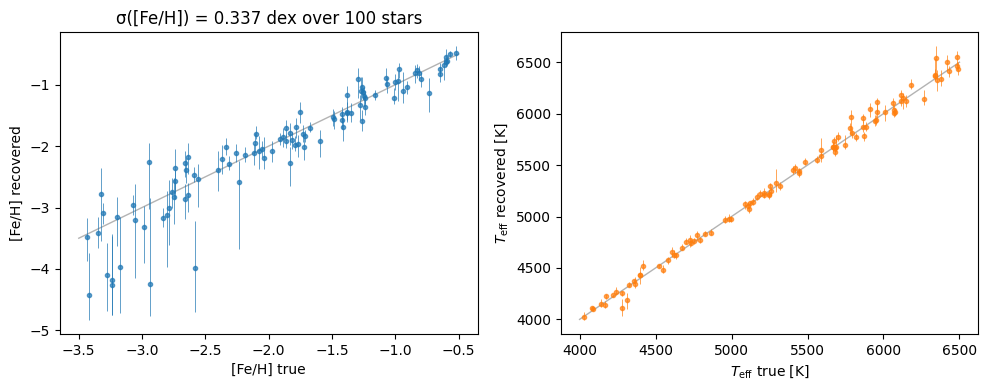

In [7]:
feh_med = np.median(np.asarray(cat_samples["feh"]), axis=1)
feh_lo, feh_hi = np.percentile(np.asarray(cat_samples["feh"]), [16, 84], axis=1)
teff_med = np.median(np.asarray(cat_samples["teff"]), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].errorbar(
    truths["feh"],
    feh_med,
    yerr=[feh_med - feh_lo, feh_hi - feh_med],
    fmt="o",
    ms=3,
    lw=0.7,
    alpha=0.7,
)
axes[0].plot([-3.5, -0.5], [-3.5, -0.5], color="0.7", lw=1, zorder=0)
scatter = np.std(feh_med - truths["feh"])
axes[0].set(
    xlabel="[Fe/H] true",
    ylabel="[Fe/H] recovered",
    title=f"σ([Fe/H]) = {scatter:.3f} dex over {N_STARS} stars",
)
axes[1].errorbar(
    truths["teff"],
    teff_med,
    yerr=np.abs(np.percentile(np.asarray(cat_samples["teff"]), [16, 84], axis=1) - teff_med),
    fmt="o",
    ms=3,
    lw=0.7,
    alpha=0.7,
    color="C1",
)
axes[1].plot([4000, 6500], [4000, 6500], color="0.7", lw=1, zorder=0)
axes[1].set(xlabel=r"$T_{\rm eff}$ true [K]", ylabel=r"$T_{\rm eff}$ recovered [K]")
plt.tight_layout()
plt.show()

## 5. Cross-check against NSS on one star

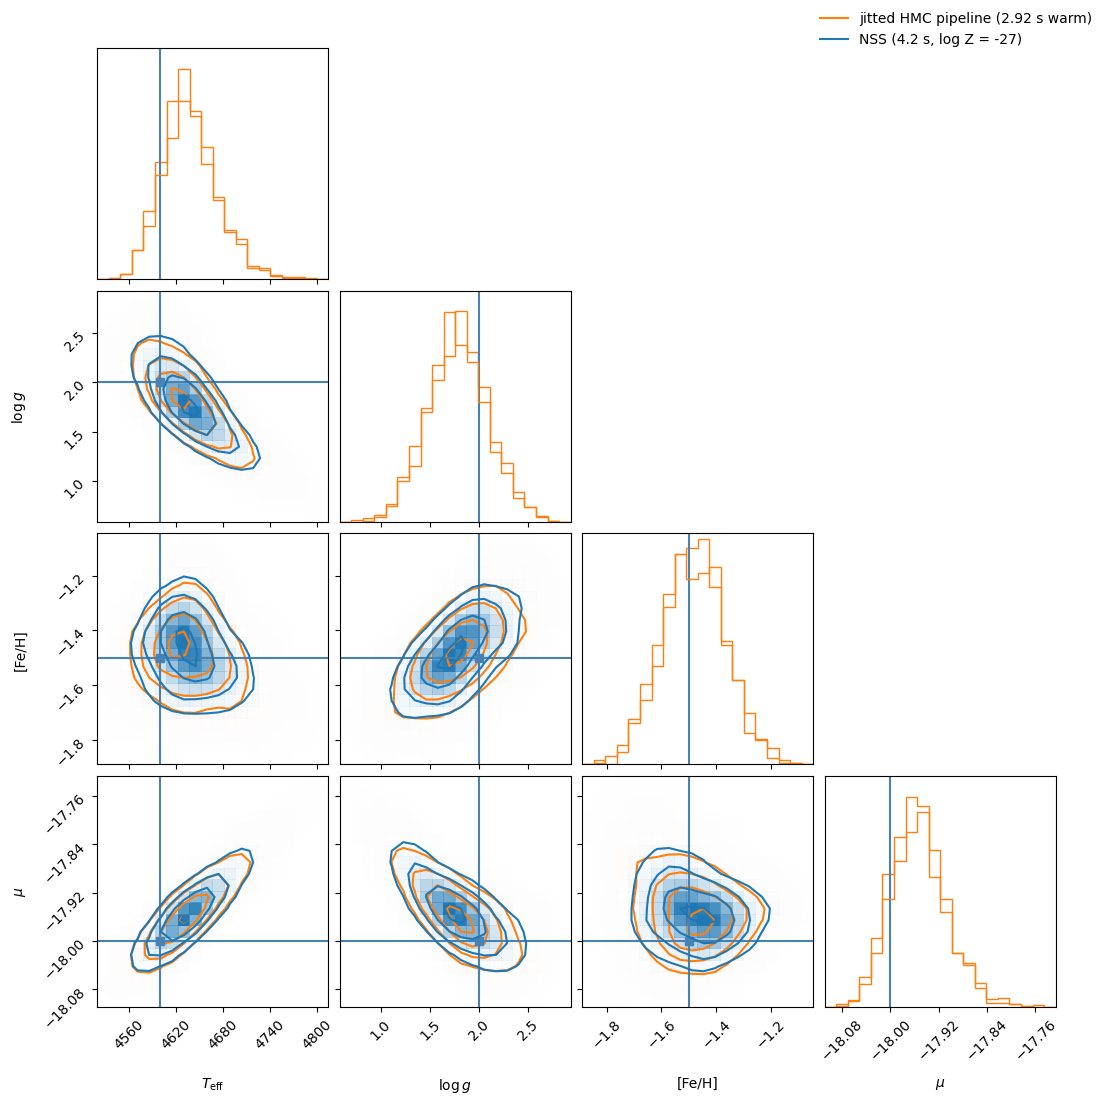

In [8]:
t0 = time.time()
nss = fit_nss(
    loglikelihood, priors, key=jax.random.PRNGKey(4), data=mags_obs, n_live=400, num_delete=40
)
t_nss = time.time() - t0

names = list(priors)
fig = overlay_corner(
    [samples, nss.samples],
    names=names,
    labels=[r"$T_{\rm eff}$", r"$\log g$", "[Fe/H]", r"$\mu$"],
    colors=["C1", "C0"],
    legend_labels=[
        f"jitted HMC pipeline ({t_warm:.2f} s warm)",
        f"NSS ({t_nss:.1f} s, log Z = {nss.logz:.0f})",
    ],
    truths=truth,
)
plt.show()

## 6. Jitted NSS: the whole nested run in one graph too

`fit_nss` drives the sampler from a Python loop that pulls the evidence
stopping criterion to the host every iteration — hundreds of device
round-trips per star. `make_nss_pipeline` moves the loop into
`lax.while_loop` (criterion evaluated on-device, dead particles scattered
into a preallocated buffer): one graph, one launch, vmap-able core.

In [9]:

nss_pipe = make_nss_pipeline(loglikelihood, priors, n_live=400, num_delete=40)

t0 = time.time()
s_nss, i_nss = nss_pipe(jax.random.PRNGKey(6), mags_obs)
t_nss_cold = time.time() - t0
t0 = time.time()
s_nss, i_nss = nss_pipe(jax.random.PRNGKey(7), mags_obs)
t_nss_warm = time.time() - t0

print(f"jitted NSS cold (compile): {t_nss_cold:5.1f} s")
print(f"jitted NSS warm:           {t_nss_warm:5.2f} s/star")
print(
    f"  log Z = {i_nss['logz']:.1f} (python-loop fit_nss gave {nss.logz:.1f}), "
    f"ESS = {i_nss['ess']:.0f}, {i_nss['n_iterations']} iterations"
)
print(f"→ {i_nss['ess'] / t_nss_warm:.0f} effective samples per second")

jitted NSS cold (compile):   4.0 s
jitted NSS warm:            2.14 s/star
  log Z = -26.2 (python-loop fit_nss gave -26.8), ESS = 1960, 202 iterations
→ 917 effective samples per second


Catalog NSS on CPU: reuse the one compiled core sequentially. (`jax.vmap` of
`nss_pipe.run` also works and is the GPU story — but the slice-sampler's XLA
graph is large, and the vmapped compile ballooned past 10 GB RSS on this
machine; a 10 GB OOM watchdog killed it. Sequential reuse of the jitted core
is the honest CPU pattern.)

In [10]:
N_NSS = 10
keys_nss = jax.random.split(jax.random.PRNGKey(8), N_NSS)
t0 = time.time()
logzs = [nss_pipe(keys_nss[i], mags_batch[i])[1]["logz"] for i in range(N_NSS)]
t_nss_cat = time.time() - t0
print(
    f"sequential jitted NSS over {N_NSS} stars: {t_nss_cat:.1f} s → {t_nss_cat / N_NSS:.2f} s/star"
)

sequential jitted NSS over 10 stars: 30.9 s → 3.09 s/star


## 7. The Laplace approximation: a posterior for the price of an optimization

Sampling is expensive because it *explores*. If the posterior is
well-behaved, we can skip the exploration: find the peak, measure its
curvature, and call the posterior a Gaussian.

`fit_laplace` does exactly that, in the same unbounded ξ-space the gradient
samplers use:

1. **MAP** — L-BFGS on the information Hamiltonian
   $\mathcal{H}(\xi) = -\log L + \tfrac12 \xi^\top\xi$ (multi-restart, since
   a bad local optimum would poison everything downstream).
2. **Hessian** — $\mathbf{H} = \nabla^2 \mathcal{H}(\xi_{\rm MAP})$ by
   automatic differentiation: exact, not finite-differenced, and cheap at
   $d = 4$.
3. **Covariance** — $\Sigma = \mathbf{H}^{-1}$, computed through an
   eigendecomposition so flat/negative curvature directions (grid edges!) get
   clipped to a positive floor instead of silently producing NaNs.
4. **Draws** — $\xi \sim \mathcal{N}(\xi_{\rm MAP}, \Sigma)$, pushed through
   each prior's bounded transform into physical units. They are **iid**: no
   autocorrelation, so ESS = number of draws.

And the evidence comes free:

$$\log Z \approx -\mathcal{H}(\xi_{\rm MAP}) - \tfrac12 \log\det \mathbf{H}$$

Note what is *absent*: the usual $(d/2)\log 2\pi$ Laplace volume factor. In
ξ-space the prior is a unit Gaussian whose $(2\pi)^{-d/2}$ normalization
cancels it exactly. (Including it inflates log Z by 3.7 nats here — a bug the
test suite caught by cross-checking against the nested-sampling evidence.)

**The optimizer must live on the device.** `fit_laplace` drives scipy's
L-BFGS-B, which round-trips to the host once per iteration — that alone costs
~2 s, swamping the millisecond Hessian. `make_laplace_pipeline` puts
*everything* in one jitted graph: multi-restart BFGS
(`jax.scipy.optimize.minimize`, vmapped over restarts), the exact Hessian,
the eigen-repaired inverse, the evidence, and the draws. Measured below:
~30x faster, and now genuinely milliseconds.

In [11]:
laplace = make_laplace_pipeline(loglikelihood, priors, n_samples=2000, n_restarts=4)
_ = jax.block_until_ready(laplace(jax.random.PRNGKey(8), mags_obs))  # compile

t0 = time.time()
lap_samples, lap_info = jax.block_until_ready(laplace(jax.random.PRNGKey(9), mags_obs))
t_lap = time.time() - t0

lap_ess = 2000.0  # draws are iid by construction
print(f"Laplace (device-side): {t_lap * 1000:.0f} ms/star  ({lap_ess:.0f} iid draws)")
print(f"  log Z = {float(lap_info['logz']):.1f}   (NSS gave {nss.logz:.1f})")
print(f"  → {lap_ess / t_lap:.0f} effective samples per second")
for n in priors:
    q = np.percentile(np.asarray(lap_samples[n]), [16, 50, 84])
    print(f"  {n:5s} truth {truth[n]:9.2f}:  {q[1]:9.2f}  68% [{q[0]:9.2f}, {q[2]:9.2f}]")

Laplace (device-side): 77 ms/star  (2000 iid draws)
  log Z = -26.4   (NSS gave -26.8)
  → 25917 effective samples per second
  teff  truth   4600.00:    4635.40  68% [  4599.94,   4668.08]
  logg  truth      2.00:       1.76  68% [     1.47,      2.07]
  feh   truth     -1.50:      -1.47  68% [    -1.60,     -1.35]
  mu    truth    -18.00:     -17.96  68% [   -18.00,    -17.91]


### Is the Gaussian a good approximation here?

Overlay it on the exact nested-sampling posterior. Where the contours agree,
Laplace bought the same answer for ~1/1000 of the compute.

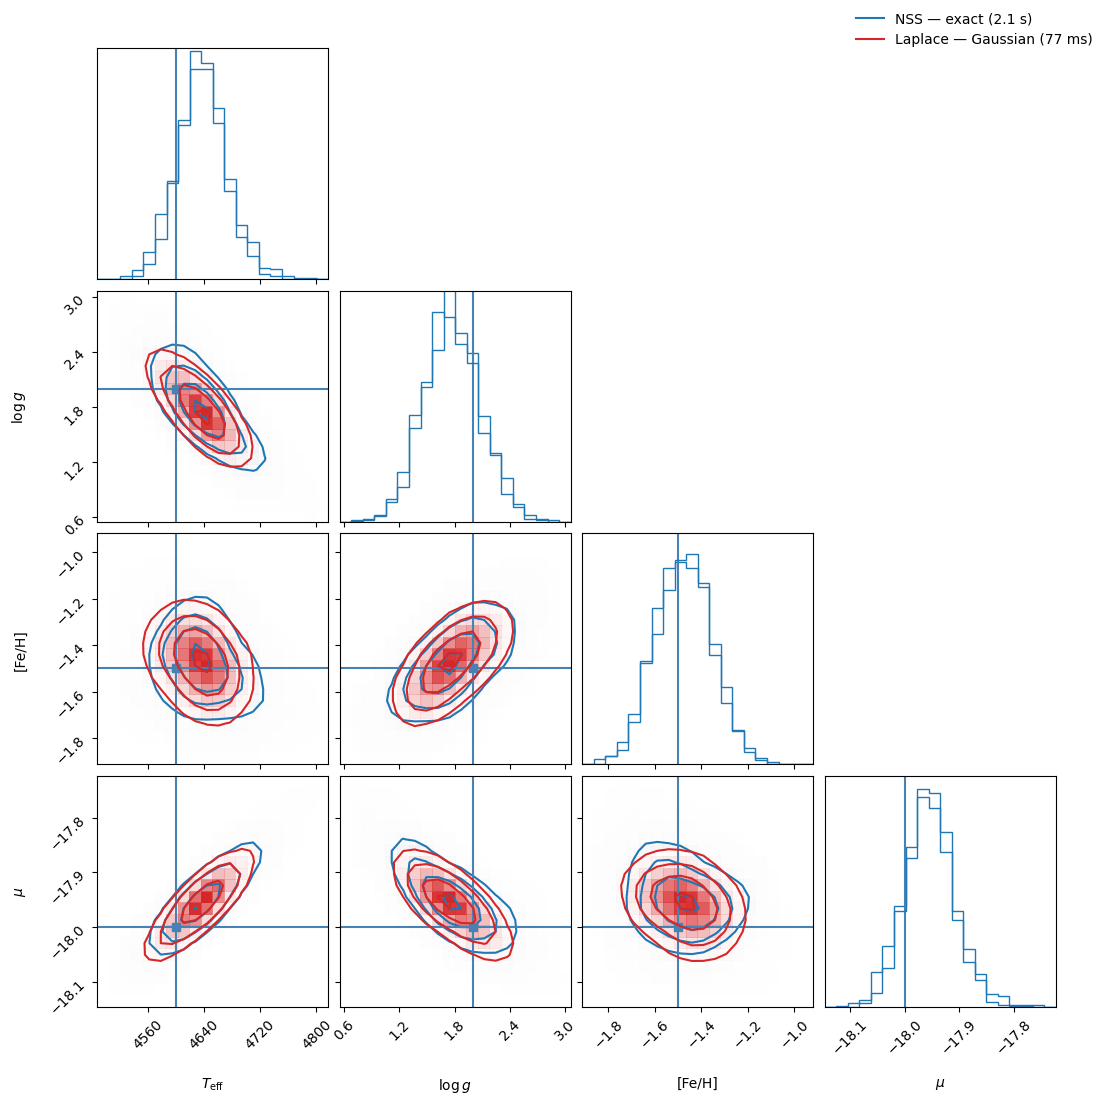

In [12]:
fig = overlay_corner(
    [nss.samples, lap_samples],
    names=names,
    labels=[r"$T_{\rm eff}$", r"$\log g$", "[Fe/H]", r"$\mu$"],
    colors=["C0", "C3"],
    legend_labels=[
        f"NSS — exact ({t_nss_warm:.1f} s)",
        f"Laplace — Gaussian ({t_lap * 1000:.0f} ms)",
    ],
    truths=truth,
)
plt.show()

**When Laplace lies.** It sees exactly one mode and reports it with
confidence. On the dwarf/giant bimodality of notebook 04 — where the
photometry genuinely admits two solutions — it would pick whichever basin the
optimizer landed in and quote a tight, wrong error bar. The same caveat kills
its evidence for model comparison across modes. Validate against NSS on a
representative subset, *then* use Laplace for throughput.

**Caveat that cost us a bug:** BFGS from random starts converged to a *local*
optimum on the 21-band posterior of notebook 03 — Hamiltonian 640 instead of
12, evidence 600 nats wrong. `make_laplace_pipeline` therefore scans the prior
box (512 cheap likelihood evaluations) and seeds its restarts from the best
points. A Gaussian is only as good as the peak it is expanded around: always
cross-check log Z against NSS on a subset.

### Catalogs: `lax.map` or `vmap`? Measure, don't assume.

Both walk a catalog through a jitted pipeline, but they build very different
graphs:

- **`vmap`** compiles a *batch-sized* graph: compile cost grows with the
  catalog, execution is vectorized.
- **`lax.map`** (scan-based) compiles the *single-star* body once and walks
  the catalog on-device: compile stays flat, execution is sequential but free
  of host round-trips.

Which wins depends on the graph — and the answer flips between our samplers.

In [13]:
N_CAT = 50
laplace_lax_map = jax.jit(lambda k, m: jax.lax.map(lambda km: laplace(km[0], km[1]), (k, m)))
laplace_vmap = jax.jit(jax.vmap(laplace))

_ = jax.block_until_ready(laplace_lax_map(keys[:N_CAT], mags_batch[:N_CAT]))  # compile
t0 = time.time()
cat_lap, cat_lap_info = jax.block_until_ready(laplace_lax_map(keys[:N_CAT], mags_batch[:N_CAT]))
t_lax = time.time() - t0

t0 = time.time()
jax.block_until_ready(laplace_vmap(keys[:N_CAT], mags_batch[:N_CAT]))
t_vmap = time.time() - t0

print(f"Laplace catalog, {N_CAT} stars:")
print(f"  lax.map (warm):             {t_lax:6.2f} s → {t_lax / N_CAT * 1000:6.0f} ms/star")
print(f"  vmap (cold: compile + run): {t_vmap:6.1f} s")
print(f"HMC catalog (section 3, vmap): {t_cat_warm / N_STARS * 1000:.0f} ms/star")

Laplace catalog, 50 stars:
  lax.map (warm):               6.97 s →    139 ms/star
  vmap (cold: compile + run):   34.8 s
HMC catalog (section 3, vmap): 834 ms/star


**The measured verdict** (this machine, CPU; `bench/benchmark_compile.py`):

| | `lax.map` | `vmap` |
|---|---|---|
| **Laplace** (100 stars) | **204 ms/star** | 1631 ms/star |
| **HMC** (20 stars) | 2.90 s/star | **1.37 s/star** |

"Always use `lax.map`" would be wrong: it is an **8x win for Laplace** and a
**2x loss for HMC**. The reason is structural.

- Laplace's graph is *small and awkward to vectorize* — BFGS control flow plus
  a 4x4 `eigh`. `vmap` inflates it into a batch-sized graph whose compile cost
  dwarfs the work, for almost no vectorization payoff.
- HMC's graph is a *big compute-bound leapfrog scan* — dense linear algebra
  that vectorizes beautifully, so `vmap` amortizes its larger compile many
  times over.

So **`lax.map` is the fast path for Laplace** (and the memory-safe path in
general — it was `vmap` of the NSS core that blew past a 10 GB watchdog),
while **HMC keeps `vmap`**. On a GPU the balance shifts toward `vmap` for
both: wide batches are what the hardware wants.

One more thing this explains: **the persistent JAX cache cannot rescue a cold
start.** tengri auto-enables an on-disk compilation cache, but it stores the
*XLA compile* (HLO → executable) — it cannot cache Python-level **tracing and
lowering**, which for a batch-sized graph is the dominant cost. Keeping graphs
single-star-sized (`lax.map`) is what actually keeps compiles cheap.

## 8. Cost summary: wall time is not the metric — ESS/second is

A sampler is only as fast as the *independent* samples it delivers. A chain
of 1000 draws with an autocorrelation time of 30 bought ~33 independent
samples, however quickly it ran. So the honest cost metric is **effective
samples per second**.

**Caveat on comparing ESS definitions.** For HMC it is autocorrelation-based
(Geyer initial-positive-sequence — the Stan estimator, `effective_sample_size`).
For nested sampling it comes from the run's importance weights. For Laplace
the draws are iid by construction, so ESS is simply the number of draws.
All three answer "how many independent draws did I buy", by different routes:
trust the factor-level differences, not the fine grain.

In [14]:
ess_nss = i_nss["ess"]
rows = [
    ("Laplace (device-side)", t_lap, lap_ess, lap_ess / t_lap),
    ("jitted NSS pipeline", t_nss_warm, ess_nss, ess_nss / t_nss_warm),
    ("python-loop NSS (fit_nss)", t_nss, nss.ess, nss.ess / t_nss),
    ("jitted HMC pipeline", t_warm, min_ess_hmc, min_ess_hmc / t_warm),
]
print(f"{'method':<28s}{'wall [s]':>10s}{'ESS':>8s}{'ESS/s':>10s}")
for name, wall, ess, rate in rows:
    print(f"{name:<28s}{wall:10.2f}{ess:8.0f}{rate:10.0f}")
print(f"\nsingle likelihood evaluation: {per_eval_us:.1f} µs")
print(f"HMC catalog vmap: {t_cat_warm / N_STARS:.2f} s/star")

method                        wall [s]     ESS     ESS/s
Laplace (device-side)             0.08    2000     25917
jitted NSS pipeline               2.14    1960       917
python-loop NSS (fit_nss)         4.23    2030       480
jitted HMC pipeline               2.92     173        59

single likelihood evaluation: 9.1 µs
HMC catalog vmap: 0.83 s/star


## When to use which — the verdict

Measuring ESS and adding Laplace overturns the naive wall-clock ranking:

- **Laplace** — Gaussian posterior + log Z in milliseconds, iid draws.
  The catalog workhorse for unimodal, well-constrained stars — *after* it has
  been validated against NSS on a representative subset.
- **NSS** — exact posterior, evidence, multimodal-safe, near-independent
  draws. The reference, and the only safe choice on degenerate stars
  (dwarf/giant) or for model comparison.
- **jitted HMC** — exact posterior with `vmap` catalog throughput; best when
  the parameter count grows and the posterior stays unimodal.
- **MAP** — point estimate: initialization and triage.

Three things the numbers taught us:

- **Nested sampling is not the slow one.** Its draws are near-independent, so
  per *independent* sample it beats every gradient sampler here — and hands
  you log Z for free.
- **HMC's raw speed is partly an illusion**: an autocorrelated chain of 1000
  draws is worth a few hundred. It still wins on catalog throughput under
  `vmap`.
- **Reusing `tuned_params` across stars is a trap.** A step size and mass
  matrix tuned on star A mixes badly on star B — `bench/benchmark_samplers.py`
  shows adapt-once reuse collapsing ESS by an order of magnitude, wiping out
  the time it saves. The jitted pipeline adapts *inside* the graph, per star,
  which is why it keeps both the speed and the ESS.

Production recipe for a MAGIC-scale catalog: **Laplace for every star**
(milliseconds), **NSS for the stars it cannot be trusted on** — flagged by low
acceptance, poor χ², dwarf/giant tension, or a Laplace-vs-NSS disagreement on
a validation subset.